## Training Notebook Requirement

The training notebook must save `model_config.json` after training completes.

**Add this function to your training notebook (secbert_smaller_teacher.ipynb) after training:**

```python


# Call after training:
# 
```

## Random Seed

In [1]:
import random
import torch
import numpy as np
import json


In [2]:
# Import reusable functions and classes from shared_utils
from shared_utils import (
    set_seed,
    convert_span_to_number,
    process_batch,
    process_batch_wrapper,
    process_data,
    count_lines,
    load_counter,
    MultiTaskIterableDataset,
    BufferedShuffleDataset,
    ProcessedIterableDataset,
    MultiTaskModel,
    GateHead,
    FocalLoss,
    CB_CE_Loss,
    hits_at_k,
    compute_loss,
    load_model_config,
    save_model_config,
    evaluate_model,
    evaluate_classification,
    evaluate_regression,
    evaluate_model_with_gate_filter
)

/home/mo1om/code/miniconda/envs/XBRL/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print(torch.__version__)

2.9.0+cu130


## Dataset

In [4]:
from transformers import AutoTokenizer
import torch

# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
# tokenizer = AutoTokenizer.from_pretrained("yiyanghkust/finbert-pretrain", local_files_only=True)
tokenizer = AutoTokenizer.from_pretrained("nlpaueb/sec-bert-base")

# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", local_files_only=True)

# 設定預設值
CLASSIFICATION_MISSING_VALUE = -100
NUMERIC_MISSING_VALUE = torch.finfo(torch.float32).max  # 3.4028235e+38

#### IterableDataset

#### Load Processed Iterable Dataset

In [5]:

train_files = ["processed_iterable_dataset/train_400k.jsonl"]
valid_files = ["processed_iterable_dataset/valid_50k.jsonl"] 
test_files = ["processed_iterable_dataset/test_50k.jsonl"]

In [6]:
# Read pre-processed JSONL files
from torch.utils.data import DataLoader
from shared_utils import ProcessedIterableDataset


In [7]:
train_dataset = ProcessedIterableDataset(train_files)

valid_dataset = ProcessedIterableDataset(valid_files)

test_dataset = ProcessedIterableDataset(test_files)

batch_size = 256
num_workers=10
# train_loader = DataLoader(train_dataset, batch_size = batch_size, num_workers = 4, drop_last = False)
# valid_loader = DataLoader(valid_dataset, batch_size = batch_size, num_workers = 4, drop_last = False)
# test_loader = DataLoader(test_dataset, batch_size = batch_size, num_workers = 4, drop_last = False)

train_loader = DataLoader(train_dataset, batch_size = batch_size, num_workers = num_workers)
valid_loader = DataLoader(valid_dataset, batch_size = batch_size, num_workers = num_workers)
test_loader = DataLoader(test_dataset, batch_size = batch_size, num_workers = num_workers)

In [8]:
import os
from shared_utils import count_lines

# Calculate approximate batch counts
train_total_samples = sum(count_lines(f) for f in train_files)
train_approx_batches = train_total_samples // batch_size

valid_total_samples = sum(count_lines(f) for f in valid_files)
valid_approx_batches = valid_total_samples // batch_size

test_total_samples = sum(count_lines(f) for f in test_files)
test_approx_batches = test_total_samples // batch_size


print(f"Train 預計數量: {train_total_samples}, 預計 {train_approx_batches} 個 batch")
print(f"Valid 預計數量: {valid_total_samples}, 預計 {valid_approx_batches} 個 batch")
print(f"Test 預計數量: {test_total_samples}, 預計 {test_approx_batches} 個 batch")


Train 預計數量: 728821, 預計 2846 個 batch
Valid 預計數量: 91168, 預計 356 個 batch
Test 預計數量: 90337, 預計 352 個 batch


## Count

#### 計算 tag, scale, negative, time 的類別個數
計算後存成 JSON，之後可以直接用

In [9]:
# IterableDataset

with open('../processed_data_task1_smaller/counter/tag_count_train_400k.json', 'r', encoding = 'utf-8') as file:
# with open('processed_iterable_dataset/counter/train_8k.json', 'r', encoding = 'utf-8') as file:
# with open('../processed_data_task1/counter/tag_count_train_data.json', 'r', encoding = 'utf-8') as file:    
    tag_counter = json.load(file)
    
# 想讓數量多的類別在前面

tag_counter = dict(sorted(tag_counter.items(), key = lambda item:item[1], reverse=True))
print(len(tag_counter))
count_threshold = 10
standard_rare_tags = {tag for tag, count in tag_counter.items() if count < count_threshold}
tag_list = [tag for tag in tag_counter.keys() if tag not in standard_rare_tags]
print(tag_list[:5])
print(f'Length of standard_rare_tags: {len(standard_rare_tags)}')
print(f'Length of all tags: {len(tag_list)}')

id2tag = {idx: tag for idx, tag in enumerate(tag_list)}
tag2id = {tag: idx for idx, tag in enumerate(tag_list)}

time_list = ['instant; past', 'instant; current', 'instant; future', 'period; past', 'period; current', 'period; future', 'period; past_current', 'period; current_future', 'period; past_future']
id2time = {idx: time for idx, time in enumerate(time_list)}
time2id = {time: idx for idx, time in enumerate(time_list)}

scale_list = [str(i) for i in range(-12, 13)]
id2scale = {idx: scale for idx, scale in enumerate(scale_list)}
scale2id = {scale: idx for idx, scale in enumerate(scale_list)}
# with open('processed_data_task1_smaller/counter/train_100k.json')

978
['custom', 'standard_rare', 'us-gaap:DebtInstrumentInterestRateStatedPercentage', 'us-gaap:DebtInstrumentBasisSpreadOnVariableRate1', 'us-gaap:DebtInstrumentFaceAmount']
Length of standard_rare_tags: 0
Length of all tags: 978


In [10]:
# load counter result

def load_counter(target_attr):
    target_path = f'processed_iterable_dataset/counter/secbert_train_small_{target_attr}.json'

    with open(target_path, "r", encoding='utf-8') as f:
        data = json.load(f)
    return data

train_tag_counts = load_counter("tag")
train_tag_counts.pop('-100', None)
num_tag_samples = [train_tag_counts.get(str(tag2id[tag]), 0) for tag in tag_list]
print(f'Total tag class: {len(train_tag_counts)}')
train_time_counts = load_counter("time")
train_time_counts.pop('-100', None)
num_time_samples = [train_time_counts.get(str(time2id[time]), 0) for time in time_list]
print(train_time_counts)

train_neg_counts = load_counter("negative")
train_neg_counts.pop('-100', None)
num_neg_samples = [train_neg_counts.get(neg, 0) for neg in sorted(train_neg_counts.keys())]
print(train_neg_counts)

train_scale_counts = load_counter("scale")
train_scale_counts.pop('-100', None)
num_scale_samples = [train_scale_counts.get(str(scale2id[scale]), 0) for scale in scale_list]
print(train_scale_counts)

Total tag class: 978
{'6': 70691, '4': 124746, '3': 175155, '1': 195615, '0': 135307, '2': 14182, '5': 10629, '7': 351, '8': 490}
{'0': 701747, '1': 19527}
{'18': 328811, '10': 117673, '12': 152722, '15': 50895, '21': 18758, '8': 1695, '17': 38, '14': 13, '9': 20, '11': 18, '13': 17, '24': 30, '16': 37, '20': 2, '6': 5, '19': 3}


## Model

# SecBERT Multi-Task Model — Inference & Evaluation

**Refactored Testing Notebook** (v2.0)

This notebook loads a trained multi-task model and evaluates it on test data.

## Key Changes:
✅ Loads `model_config.json` instead of recomputing ID mappings from raw data
✅ Eliminates the critical ID shift bug between training and testing
✅ Strict CPU/CUDA device handling
✅ Dynamic checkpoint configuration (easy switching)
✅ Identical model definitions to training notebook

## Prerequisites:
1. Training notebook must save `model_config.json` (see section below)
2. Model checkpoint must exist at `model_weight/{MODEL_NAME}/{RUN_DATE}_{RUN_INDEX}_step{CHECKPOINT_STEP}.pt`
3. Test data must be available at the configured path

## Loss

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
# device = 'cpu'

cuda


In [12]:
# time loss
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np
from torch import nn

# 取得 time 類別的出現次數
time_class_counts = torch.tensor(num_time_samples)

total_samples = sum(train_time_counts.values())
num_classes = len(train_time_counts)

time_class_weights = {
    cls: total_samples / (num_classes * count) 
    for cls, count in train_time_counts.items()
}
time_class_weights = dict(sorted(time_class_weights.items(), key = lambda item:item[0]))
time_class_weights = list(time_class_weights.values())

time_smoothed_weights = np.log1p(time_class_weights)

MIN_WEIGHT =  1 # 設定最小值
time_smoothed_weights = np.clip(time_smoothed_weights, MIN_WEIGHT, None)
time_smoothed_weights[0] = 1.5
time_smoothed_weights[6] = 1.5
print(time_smoothed_weights)
time_class_weights = torch.tensor(time_smoothed_weights, dtype=torch.float).to(device)
time_loss_fn = nn.CrossEntropyLoss(weight = time_class_weights, ignore_index = CLASSIFICATION_MISSING_VALUE)

[1.5        1.         1.90167407 1.         1.         2.15193528
 1.5        5.44323412 5.11132642]


In [13]:
# scale loss
scale_class_weights = {
    15: 1.2,  21: 1.5
}
num_classes = len(scale_list)
weights_list = [scale_class_weights.get(i, 1.0) for i in range(num_classes)]

scale_class_weights = torch.tensor(weights_list, dtype=torch.float).to(device)

# 定義 loss function
scale_loss_fn = nn.CrossEntropyLoss(weight=scale_class_weights, ignore_index=CLASSIFICATION_MISSING_VALUE)

In [14]:
from torch import nn
# --- Tag Loss ---
# (Assumes you have num_tag_samples defined as before)
tag_loss_fn = CB_CE_Loss(num_tag_samples, beta=0.99, ignore_index=CLASSIFICATION_MISSING_VALUE)

# --- Time Loss ---
# (Assumes you have time_class_weights defined as before)
# Note: standard CrossEntropyLoss supports reduction='none' by default
time_loss_fn = nn.CrossEntropyLoss(weight=time_class_weights, ignore_index=CLASSIFICATION_MISSING_VALUE, reduction='none')

# --- Scale Loss ---
# (Assumes scale_class_weights defined)
scale_loss_fn = nn.CrossEntropyLoss(weight=scale_class_weights, ignore_index=CLASSIFICATION_MISSING_VALUE, reduction='none')

# --- Negative Loss ---
neg_loss = FocalLoss(alpha=0.25, gamma=3.0, reduction="none")

In [15]:
# # train_time_counts = get_value_counts(train_loader, "time")
# # num_time_samples = [train_time_counts.get(time, 0) for time in sorted(train_time_counts.keys())]
# time_loss_fn = CB_CE_Loss(num_time_samples)

In [16]:
from torch import nn
CLASSIFICATION_MISSING_VALUE=-100
classification_loss = nn.CrossEntropyLoss(ignore_index = CLASSIFICATION_MISSING_VALUE)
mse_loss = nn.MSELoss()


In [17]:
# def compute_loss(outputs, targets, values, task_weights = None, hits_k = False):
#     losses = {}
#     tag_hits_k = {}
#     if "tag" in targets:
#         losses["tag"] = tag_loss_fn(outputs["tag"], targets["tag"])

#         if hits_k:
#             tag_hits_k["hits_1"] = hits_at_k(outputs["tag"], targets["tag"], k = 1)
#             tag_hits_k["hits_3"] = hits_at_k(outputs["tag"], targets["tag"], k = 3)
#             tag_hits_k["hits_5"] = hits_at_k(outputs["tag"], targets["tag"], k = 5)

#     if "time" in targets:
#         losses["time"] = time_loss_fn(outputs["time"], targets["time"])
    
#     if "scale" in targets:
#         losses["scale"] = scale_loss_fn(outputs["scale"], targets["scale"])
    

#     if "negative" in targets:
#         losses["negative"] = neg_loss(outputs["negative"], targets["negative"])
    
#     # gate: [batch_size, 1] -> [batch_size]
#     gate = outputs["gate"].squeeze(-1)
    
#     # Compute weighted sum of task losses: sum over tasks
#     # Each task loss is a scalar (already reduced by their respective loss functions)
#     total_raw_loss = sum(task_weights[k] * losses[k] for k in losses.keys())
    
#     # Apply gate weighting and regularization
#     # (1 - gate) * total_loss +  gate^2
#     weighted_loss = (1 - gate) * total_raw_loss + gate.pow(2)
    

#     # Normalize by task weights sum
#     total_loss = weighted_loss / sum(task_weights.values())
#     return (total_loss, losses, tag_hits_k) if hits_k else (total_loss, losses)   

# 恢復訓練

In [18]:
import wandb
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.functional as F
from transformers import get_scheduler
from tqdm import tqdm
import os

num_warmup_steps = 5
num_epochs = 30
eval_step = 20000 # 150222 個 batch
# checkpoint_save_step = 50
task_weights = {"tag": 10.0, "time": 0.3, "scale": 0.2, "negative": 10.0}  
# task_weights = get_task_weights(0)
patience = 5
max_saved_models = 2
saved_models = [] 

model_name = "secbert"
date = "0426"
index = 173
run_name = f"{model_name}-{date}-{index}"

model = MultiTaskModel(
    "nlpaueb/sec-bert-base",
    num_tags = len(tag_list), 
    num_times = len(time_list),
    num_scales= len(scale_list)
)


bert_lr = 1e-5
tag_head_lr = 5e-4
time_head_lr = 1e-5
scale_head_lr = 3e-5
negative_head_lr = 2e-5

optimizer = AdamW([
    {"params": model.bert.parameters(), "lr": bert_lr, "weight_decay": 1e-2},  
    {"params": model.tag_head.parameters(), "lr": tag_head_lr,  "weight_decay": 1e-2},  
    {"params": model.time_head.parameters(), "lr": time_head_lr,  "weight_decay": 1e-2},  
    {"params": model.scale_head.parameters(), "lr": scale_head_lr,  "weight_decay": 1e-2},
    {"params": model.negative_head.parameters(), "lr": negative_head_lr,  "weight_decay": 1e-2},  
])

# num_total_steps= num_epochs * train_approx_batches
# scheduler = CosineAnnealingLR(optimizer, T_max = num_total_steps // 4, eta_min = 1e-7)

device = "cuda" if torch.cuda.is_available() else "cpu"
# device = 'cpu'
print(device)
best_val_loss = float("inf")
early_stop_counter = 0 


os.makedirs(f'model_weight/{model_name}', exist_ok=True)
os.makedirs(f'check_point/{model_name}', exist_ok=True)


# import wandb

# # generate a new run name or ID if needed
# run_name = f"{model_name}-{date}-{index}-gate_mechanism"

# wandb.init(
#     project="multi-task-model",
#     name=run_name,
#     # Remove 'id' and 'resume' if this is a fresh start for the new model logic
#     # id='new_id_here', 
#     # resume="allow", 
#     config={
#         "epochs": num_epochs,
#         "batch_size": batch_size,
#         "learning_rates": { 
#             "bert": bert_lr,
#             "tag_head": tag_head_lr,
#             "time_head": time_head_lr,
#             "scale_head": scale_head_lr,
#             "negative_head": negative_head_lr,
#             "gate_head": bert_lr # or whatever custom LR you used for gate
#         },
#         "task_weights": task_weights,
#         "train_data_size": train_total_samples,
#         "model_architecture": "SecBERT + GateHead + HybridLoss"
#     }
# )

# # Optional: Watch the model to see gradients (specifically helpful to see if GateHead is dying)
# wandb.watch(model, log="gradients", log_freq=100)
# # wandb.watch(model, log="all")

 

cuda


In [19]:
# ---------------------------------------------------------
# ONLY RUN THIS CELL AFTER YOUR MODEL IS DEFINED AND TRAINED
# ---------------------------------------------------------
model_name="secbert"
# Ensure output directory exists (based on your script variables)
output_dir = os.path.join("model_weight", model_name) # e.g. model_weight/secbert

save_model_config(
    model=model,      # This variable must exist!
    tag2id=tag2id,    # This variable must exist!
    time2id=time2id,  # This variable must exist!
    scale2id=scale2id, # This variable must exist!
    output_dir=output_dir,
    run_name=run_name # This variable must exist!
)

✅ Configuration saved to: model_weight/secbert/secbert-0426-173_config.json


'model_weight/secbert/secbert-0426-173_config.json'

# Test

In [28]:
# ========================================================================
# ===== IMPROVED EVALUATION FUNCTION (Compatible with Multi-Gate Model) =====
# ========================================================================

import numpy as np
import pandas as pd
from collections import defaultdict
import csv
from tqdm import tqdm
import os
import torch

def evaluate_model(
    model,
    test_loader,
    device,
    task_weights,
    error_file_path,
    save_errors=False,
    verbose=True
):
    """
    Evaluate the model on test data.
    Modified to handle models returning a dictionary of multiple gates.
    """
    
    os.environ["WANDB_DISABLED"] = "true"
    model.eval()
    
    all_losses = {"tag": 0, "time": 0, "fact": 0, "scale": 0, "negative": 0}
    total_hits = {"hits_1": 0, "hits_3": 0, "hits_5": 0}
    predictions = defaultdict(list)
    ground_truths = defaultdict(list)
    errors = defaultdict(list)
    
    test_batch_count = 0
    fact_results = []
    
    # Use tqdm if verbose
    loader = tqdm(test_loader, desc="Evaluating") if verbose else test_loader
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(loader):
            # ===== Load batch to device =====
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            start_tokens = batch["start_token"].to(device)
            end_tokens = batch["end_token"].to(device)
            values = batch["value"].to(device)
            
            targets = {
                "tag": batch["tag"].to(device),
                "time": batch["time"].to(device),
                "fact": batch["fact"].to(device),
                "scale": batch["scale"].to(device),
                "negative": batch["negative"].to(device)
            }
            
            # ===== Forward pass =====
            outputs = model(input_ids, attention_mask, start_tokens, end_tokens)
            
            # ===== Compute loss =====
            # Note: Ensure your compute_loss can handle the 'gates' dict or ignores it safely
            loss, losses, tag_hits_k = compute_loss(
                outputs, targets, values, task_weights, hits_k=True,tag_loss_fn=tag_loss_fn,
                time_loss_fn=time_loss_fn,
                scale_loss_fn=scale_loss_fn,
                neg_loss=neg_loss
            )
            
            # ===== Extract gate values for debugging (FIXED BLOCK) =====
            # The model returns "gates" (dict of 4 tensors) but logic expects "gate" (1 tensor)
            if "gate" in outputs:
                # Case 1: Model returns a single gate tensor
                gate_tensor = outputs["gate"]
            elif "gates" in outputs and isinstance(outputs["gates"], dict):
                # Case 2: Model returns a dict of task-specific gates
                # Solution: Average the 4 gates to get a single "noise score" for logging
                gates_dict = outputs["gates"]
                # Sum all gate tensors (tag + time + scale + negative)
                sum_gates = sum(gates_dict.values()) 
                # Divide by number of tasks to get average
                gate_tensor = sum_gates / len(gates_dict)
            else:
                # Case 3: Fallback (should not happen with correct model)
                gate_tensor = torch.zeros(input_ids.size(0), 1).to(device)

            # Now we have a single tensor to convert to list
            gate_values = gate_tensor.squeeze(-1).cpu().tolist()
            predictions["gate"].extend(gate_values)
            
            test_batch_count += 1
            
            # ===== Aggregate metrics =====
            if tag_hits_k:
                for key in total_hits:
                    total_hits[key] += tag_hits_k[key]
            
            for key in all_losses:
                if key in losses:
                    val = losses[key]
                    if isinstance(val, torch.Tensor):
                        all_losses[key] += val.item()
                    else:
                        all_losses[key] += val
            
            # ===== Classification predictions (tag, time, scale, negative) =====
            for key in ["scale", "negative", "tag", "time"]:
                pred = torch.argmax(outputs[key], dim=-1).cpu().tolist()
                true = targets[key].cpu().tolist()
                
                for i, (p, t) in enumerate(zip(pred, true)):
                    predictions[key].append(p)
                    ground_truths[key].append(t)
                    
                    if p != t:
                        errors[key].append({
                            "batch_idx": batch_idx,
                            "sample_idx": i,
                            "true": t,
                            "pred": p,
                            "gate": gate_values[i]
                        })
            
            # ===== Fact (Numeric) Predictions =====
            if "fact" in targets:
                negative_pred = outputs["negative"].argmax(dim=-1).cpu().numpy()
                
                if "scale" in outputs:
                    scale_pred_class = outputs["scale"].argmax(dim=-1).cpu().numpy()
                else:
                    scale_pred_class = np.ones_like(
                        values.cpu().numpy(), dtype=np.int64
                    )
                
                # Convert scale IDs to actual scale values
                id2scale_np = np.array(
                    [float(id2scale[idx]) for idx in range(len(id2scale))],
                    dtype=np.float64
                )
                scale_pred_values = id2scale_np[scale_pred_class]
                
                values_np = values.cpu().numpy()
                fact_pred = (
                    values_np * ((-1) ** negative_pred) * (10 ** scale_pred_values)
                )
                fact_target = targets["fact"].view(-1).cpu().numpy()
                
                for i, (p, t, neg, scale, scale_val, val) in enumerate(
                    zip(
                        fact_pred,
                        fact_target,
                        negative_pred,
                        scale_pred_class,
                        scale_pred_values,
                        values_np,
                    )
                ):
                    # Skip missing values
                    if t == NUMERIC_MISSING_VALUE or t > 1e30:
                        continue
                    
                    predictions["fact"].append(p)
                    ground_truths["fact"].append(t)
                    
                    fact_results.append({
                        "batch_idx": batch_idx,
                        "sample_idx": i,
                        "true": t,
                        "pred": p,
                        "negative_pred": int(neg),
                        "scale_pred": int(scale),
                        "scale_val": float(scale_val),
                        "value": float(val),
                        "gate": gate_values[i]
                    })
                    
                    # Check for error (absolute difference > threshold)
                    if abs(p - t) > 1e-2:
                        errors["fact"].append({
                            "batch_idx": batch_idx,
                            "sample_idx": i,
                            "true": float(t),
                            "pred": float(p),
                            "gate": gate_values[i]
                        })
    
    # ===== Average metrics =====
    for key in all_losses:
        all_losses[key] /= test_batch_count if test_batch_count > 0 else 1
    
    avg_hits_k = {
        key: total_hits[key] / test_batch_count
        for key in total_hits
        if test_batch_count > 0
    }
    
    # ===== Save errors to CSV =====
    if save_errors:
        for key, error_list in errors.items():
            if error_list:
                error_file = f"{error_file_path}_errors_{key}.csv"
                fieldnames = ["batch_idx", "sample_idx", "true", "pred", "gate"]
                with open(error_file, mode="w", newline="", encoding="utf-8") as f:
                    writer = csv.DictWriter(f, fieldnames=fieldnames)
                    writer.writeheader()
                    writer.writerows(error_list)
                if verbose:
                    print(f"🚨 {len(error_list)} {key} errors saved to {error_file}")
    
    # ===== Save fact results to CSV =====
    if fact_results:
        fact_results_df = pd.DataFrame(fact_results)
        fact_csv_path = f"{error_file_path}_fact_results.csv"
        fact_results_df.to_csv(fact_csv_path, index=False, encoding="utf-8")
        if verbose:
            print(f"💾 Fact results saved to {fact_csv_path}")
    
    if verbose:
        print(f"\n✅ Evaluation complete!")
        print(f"   Test batches: {test_batch_count}")
        print(f"   Losses: {all_losses}")
        print(f"   Hits@K: {avg_hits_k}")
    
    return all_losses, dict(predictions), dict(ground_truths), avg_hits_k

In [29]:
run_name

'secbert-0426-173'

In [30]:
model_config=load_model_config(f'model_weight/{model_name}/{run_name}'+'_config.json')

✅ Config loaded from: model_weight/secbert/secbert-0426-173_config.json


In [31]:
# ============================================================================
# ===== DYNAMIC CONFIGURATION BLOCK (Edit these to switch checkpoints!) =====
# ============================================================================
RUN_NAME = "secbert-0426-173"
MODEL_NAME = "secbert"
BASE_WEIGHT_DIR = "model_weight"

# Model checkpoint identifiers
RUN_DATE = "0426"                    # e.g., "0426" (for file naming)
RUN_INDEX = 173                      # e.g., 173
CHECKPOINT_STEP = 30001              # e.g., 20001 (the actual checkpoint to load)
OUTPUT_DATE = 1203                   # e.g., 1203 (output directory naming)

# Device handling (auto-detect, but allow override)
FORCE_CPU = False  # Set to True to force CPU even if GPU is available
device = torch.device("cpu") if FORCE_CPU else (
    torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
)
print(f"🖥️  Using device: {device}")

# Extract model args from config
model_args = model_config["model_args"]
num_tags = model_args["num_tags"]
num_times = model_args["num_times"]
num_scales = model_args["num_scales"]

# ============================================================================
# ===== CREATE MODEL INSTANCE =====
# ============================================================================

model = MultiTaskModel(
    bert_model_name=model_args["bert_model_name"],
    num_tags=num_tags,
    num_times=num_times,
    num_scales=num_scales
)

# ============================================================================
# ===== LOAD MODEL WEIGHTS (with proper error handling) =====
# ============================================================================

base_weight_dir = "model_weight"
base_error_dir = "error_analysis"

# Build checkpoint path dynamically
checkpoint_path = os.path.join(
    base_weight_dir,
    MODEL_NAME,
    f"{RUN_DATE}_{RUN_INDEX}_step{CHECKPOINT_STEP}.pt"
)
print(f"🔄 Loading model checkpoint from: {checkpoint_path}")
# Ensure checkpoint exists
if not os.path.exists(checkpoint_path):
    available_files = os.listdir(os.path.dirname(checkpoint_path)) if os.path.exists(os.path.dirname(checkpoint_path)) else []
    raise FileNotFoundError(
        f"❌ Model checkpoint not found: {checkpoint_path}\n"
        f"   Available files: {available_files[:5]}..."
    )

# Load weights with proper device mapping
try:
    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)
    print(f"✅ Model weights loaded from: {checkpoint_path}")
except RuntimeError as e:
    print(f"❌ Error loading state_dict: {e}")
    raise

# Move model to device and set to eval mode
model.to(device)
model.eval()

print(f"✅ Model ready on device: {device}")

# ============================================================================
# ===== SET UP ERROR OUTPUT DIRECTORY =====
# ============================================================================

os.makedirs(base_error_dir, exist_ok=True)
error_file_path = os.path.join(
    base_error_dir,
    f"{MODEL_NAME}_{RUN_DATE}_{RUN_INDEX}"
)

# Task weights (same as training)
task_weights = {"tag": 10.0, "time": 0.3, "scale": 0.2, "negative": 10.0}

# ============================================================================
# ===== RUN EVALUATION =====
# ============================================================================

print("\n" + "="*70)
print("STARTING EVALUATION")
print("="*70)
print(f"Model: {RUN_NAME}")
print(f"Checkpoint: Step {CHECKPOINT_STEP}")
print(f"Device: {device}")
print("="*70 + "\n")

test_all_losses, test_predictions, test_ground_truths, avg_hits_k = evaluate_model(
    model=model,
    test_loader=test_loader,
    device=device,
    task_weights=task_weights,
    error_file_path=error_file_path,
    save_errors=True,
    verbose=True,
    
)
print(test_all_losses)
print(avg_hits_k)

# ============================================================================
# ===== SAVE RESULTS TO CSV =====
# ============================================================================

attrs = ["scale", "negative", "tag", "time", "fact"]
os.makedirs("result", exist_ok=True)

for attr in attrs:
    if attr in test_predictions and attr in test_ground_truths:
        df = pd.DataFrame({
            f"true_{attr}": test_ground_truths[attr],
            f"pred_{attr}": test_predictions[attr],
        })
        
        result_path = os.path.join(
            "result",
            f"{MODEL_NAME}_{RUN_DATE}_{RUN_INDEX}_result_{attr}.csv"
        )
        
        df.to_csv(result_path, index=False, encoding="utf-8")
        print(f"✅ Saved {attr} results to {result_path} ({len(df)} samples)")

print("\n" + "="*70)
print("EVALUATION COMPLETE")
print("="*70)
print(f"Run: {RUN_NAME}")
print(f"Checkpoint: Step {CHECKPOINT_STEP}")
print(f"Device: {device}")
print(f"Total test samples: {sum(len(v) for v in test_ground_truths.values())}")
print("="*70)

🖥️  Using device: cuda
🔄 Loading model checkpoint from: model_weight/secbert/0426_173_step30001.pt
✅ Model weights loaded from: model_weight/secbert/0426_173_step30001.pt
✅ Model ready on device: cuda

STARTING EVALUATION
Model: secbert-0426-173
Checkpoint: Step 30001
Device: cuda



Evaluating: 360it [03:29,  1.72it/s]


🚨 8961 scale errors saved to error_analysis/secbert_0426_173_errors_scale.csv
🚨 2306 negative errors saved to error_analysis/secbert_0426_173_errors_negative.csv
🚨 32082 tag errors saved to error_analysis/secbert_0426_173_errors_tag.csv
🚨 18848 time errors saved to error_analysis/secbert_0426_173_errors_time.csv
🚨 3661 fact errors saved to error_analysis/secbert_0426_173_errors_fact.csv
💾 Fact results saved to error_analysis/secbert_0426_173_fact_results.csv

✅ Evaluation complete!
   Test batches: 360
   Losses: {'tag': 0.012854450687559114, 'time': 0.6867590378555987, 'fact': 0.0, 'scale': 0.05836174353349229, 'negative': 0.0028667993213780897}
   Hits@K: {'hits_1': 0.6451505432526271, 'hits_3': 0.872807099421819, 'hits_5': 0.9340255647897721}
{'tag': 0.012854450687559114, 'time': 0.6867590378555987, 'fact': 0.0, 'scale': 0.05836174353349229, 'negative': 0.0028667993213780897}
{'hits_1': 0.6451505432526271, 'hits_3': 0.872807099421819, 'hits_5': 0.9340255647897721}
✅ Saved scale resu

### Recall、Accuracy...

In [32]:
import pandas as pd
time_result = pd.read_csv('result/secbert_0426_173_result_time.csv')
tag_result = pd.read_csv('result/secbert_0426_173_result_tag.csv')
scale_result = pd.read_csv('result/secbert_0426_173_result_scale.csv')
negative_result = pd.read_csv('result/secbert_0426_173_result_negative.csv')

In [33]:
time_result.head()

,true_time,pred_time
0,3,3
1,6,4
2,0,0
3,0,0
4,1,1


In [36]:
CLASSIFICATION_MISSING_VALUE = -100

In [37]:
time_metrics = evaluate_classification(test_ground_truths['time'], test_predictions['time'], 'time')
scale_metrics = evaluate_classification(test_ground_truths['scale'], test_predictions['scale'], 'scale')
negative_metrics = evaluate_classification(test_ground_truths['negative'], test_predictions['negative'], 'negative')
fact_metrics = evaluate_regression(test_ground_truths['fact'], test_predictions['fact'], 'fact')
tag_metrics = evaluate_classification(test_ground_truths['tag'], test_predictions['tag'], 'tag')



TIME Classification Metrics:
Accuracy: 0.7937
Precision (weighted): 0.7986
Recall (weighted): 0.7937
F1 Score (weighted): 0.7944
Confusion Matrix:
[[13760   991    63  1429   194    33   272     0     0]
 [ 2345 18901   175   258  1328    94  1011     0     0]
 [  124   112  1887    21    35   183    24     0     0]
 [ 2162   226    19 17253   840    77   937     0     0]
 [  350  1296    48   966 11833   203   482     0     0]
 [   35    46   118    78   106   838    61     0     0]
 [  221   573     7   649   245    43  7014     0     0]
 [    0     2     3     1     9    22     2     0     0]
 [    1     6     1    10     4    15    25     0     3]]
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.82      0.77     16742
           1       0.85      0.78      0.82     24112
           2       0.81      0.79      0.80      2386
           3       0.83      0.80      0.82     21514
           4       0.81      0.78      0.79 

# threshold

In [38]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 5))

# # Plot 1: Tag Accuracy vs Coverage
# plt.subplot(1, 2, 1)
# plt.plot(df_tradeoff['coverage'], df_tradeoff['tag_acc'], marker='o', linestyle='-')
# plt.xlabel('Coverage (Fraction of Data Kept)')
# plt.ylabel('Tag Accuracy')
# plt.title('Accuracy vs. Coverage')
# plt.grid(True)
# plt.gca().invert_xaxis() # Usually viewed as coverage decreasing from 1.0 -> 0.0

# # Plot 2: Fact MAE vs Coverage
# plt.subplot(1, 2, 2)
# plt.plot(df_tradeoff['coverage'], df_tradeoff['fact_mae'], marker='o', color='orange', linestyle='-')
# plt.xlabel('Coverage (Fraction of Data Kept)')
# plt.ylabel('Fact MAE (Lower is Better)')
# plt.title('Error vs. Coverage')
# plt.grid(True)
# plt.gca().invert_xaxis()

# plt.tight_layout()
# plt.show()

## gate

In [39]:
# ============================================================================
# ===== GATE DISTRIBUTION ANALYSIS =====
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Run Evaluation (Updated to unpack gate_df)
test_all_losses, test_predictions, test_ground_truths, avg_hits_k, gate_df = evaluate_model(
    model=model,
    test_loader=test_loader,
    device=device,
    task_weights=task_weights,
    error_file_path=error_file_path,
    save_errors=True,
    verbose=True
)

print(test_all_losses)
print(avg_hits_k)

# 2. Basic Statistics
print("\n=== Gate Value Statistics ===")
print(gate_df['gate_value'].describe())

skewness = gate_df['gate_value'].skew()
kurt = gate_df['gate_value'].kurtosis()
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurt:.4f}")

# 3. Visualization
plt.figure(figsize=(10, 6))
sns.histplot(gate_df['gate_value'], kde=True, bins=30, color='skyblue')
plt.axvline(gate_df['gate_value'].mean(), color='red', linestyle='--', label=f"Mean: {gate_df['gate_value'].mean():.2f}")
plt.axvline(gate_df['gate_value'].median(), color='green', linestyle='-', label=f"Median: {gate_df['gate_value'].median():.2f}")
plt.title(f'Distribution of Average Gate Values\n(Skew: {skewness:.2f}, Kurt: {kurt:.2f})')
plt.xlabel('Gate Value (Average across tasks)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# 4. Outlier Detection (IQR Method)
Q1 = gate_df['gate_value'].quantile(0.25)
Q3 = gate_df['gate_value'].quantile(0.75)
IQR = Q3 - Q1
iqr_threshold = Q3 + 1.5 * IQR

print(f"\n=== Outlier Analysis ===")
print(f"IQR Threshold (Q3 + 1.5*IQR): {iqr_threshold:.4f}")
print(f"P99 Threshold: {gate_df['gate_value'].quantile(0.99):.4f}")

clean_data = gate_df[gate_df['gate_value'] <= iqr_threshold]
print(f"Original samples: {len(gate_df)}")
print(f"Clean samples (kept): {len(clean_data)}")
print(f"Dropped samples: {len(gate_df) - len(clean_data)}")

# 5. Save High Activation (Noise) Samples
# Decode text if tokenizer is available
if 'tokenizer' in globals():
    thresh_p99 = gate_df['gate_value'].quantile(0.99)
    big_gate_samples = gate_df[gate_df['gate_value'] > thresh_p99].copy()
    
    def decode_ids(id_list):
        return tokenizer.decode(id_list, skip_special_tokens=True)

    big_gate_samples['text'] = big_gate_samples['input_ids'].apply(decode_ids)
    
    # Save to CSV
    save_cols = ['batch_idx', 'sample_idx', 'gate_value', 'text']
    big_gate_samples[save_cols].to_csv('high_gate_samples_teacher.csv', index=False)
    print("✅ Saved 'high_gate_samples_teacher.csv' (Top 1% Noise)")

Evaluating: 0it [00:00, ?it/s]

Evaluating: 360it [03:29,  1.72it/s]


🚨 8961 scale errors saved to error_analysis/secbert_0426_173_errors_scale.csv
🚨 2306 negative errors saved to error_analysis/secbert_0426_173_errors_negative.csv
🚨 32082 tag errors saved to error_analysis/secbert_0426_173_errors_tag.csv
🚨 18848 time errors saved to error_analysis/secbert_0426_173_errors_time.csv
🚨 3661 fact errors saved to error_analysis/secbert_0426_173_errors_fact.csv
💾 Fact results saved to error_analysis/secbert_0426_173_fact_results.csv

✅ Evaluation complete!
   Test batches: 360
   Losses: {'tag': 0.012854450687559114, 'time': 0.6867590378555987, 'fact': 0.0, 'scale': 0.05836174353349229, 'negative': 0.0028667993213780897}
   Hits@K: {'hits_1': 0.6451505432526271, 'hits_3': 0.872807099421819, 'hits_5': 0.9340255647897721}


ValueError: not enough values to unpack (expected 5, got 4)


PERFORMANCE WITHOUT NOISE (Clean Subset)
Filtering Threshold (Gate <= 0.2471)
Kept 85019 out of 90337 samples (94.1%)

--- TIME (Clean) ---

TIME Evaluation Metrics:
Weighted F1 Score: 0.8195
Weighted Recall: 0.8189
Weighted Precision: 0.8219
Accuracy: 0.8189
F1 Score (macro): 0.6270
Precision (macro): 0.6275
Recall (macro): 0.6278

Confusion Matrix:
[[13243   955    23  1298   130     1   172     0     0]
 [ 2009 18697    84   193  1279    27   825     0     0]
 [   71    82  1788     8    28   119    13     0     0]
 [ 1919   180     2 16695   801    14   706     0     0]
 [  232  1205     9   763 11718    70   414     0     0]
 [    8    23    65    38    82   595    42     0     0]
 [  147   545     1   481   234    17  6678     0     0]
 [    1     1     0     0     8    10     2     0     0]
 [    1     2     0     3     1     2     3     0     0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.84      0.79     15822

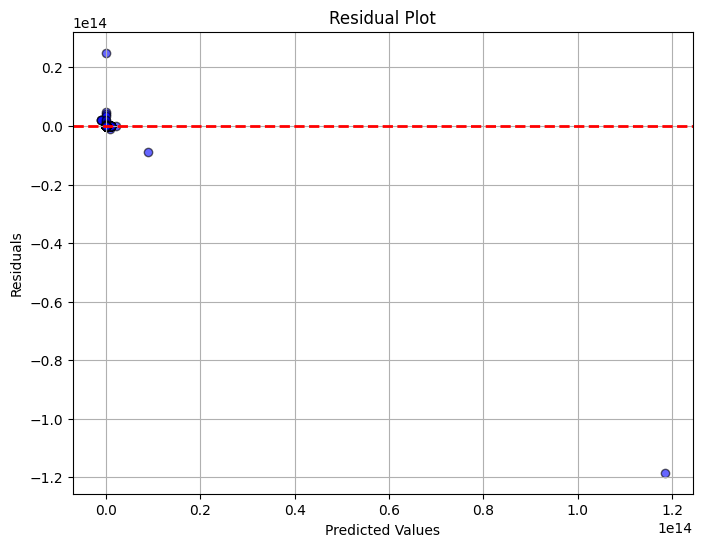

: 

In [ ]:
import numpy as np

# ============================================================================
# ===== PERFORMANCE ON CLEAN DATA (NOISE REMOVED) =====
# ============================================================================

print("\n" + "="*70)
print("PERFORMANCE WITHOUT NOISE (Clean Subset)")
print("="*70)

# 1. Define the Threshold (Using IQR Method from previous step)
# You can also set a manual threshold like: threshold = 0.5
Q1 = gate_df['gate_value'].quantile(0.25)
Q3 = gate_df['gate_value'].quantile(0.75)
IQR = Q3 - Q1
threshold = Q3 + 1.5 * IQR

print(f"Filtering Threshold (Gate <= {threshold:.4f})")

# 2. Create Boolean Mask for Clean Samples
# This creates a list of True/False values (True = Keep, False = Noise)
clean_mask = gate_df['gate_value'] <= threshold
print(f"Kept {clean_mask.sum()} out of {len(clean_mask)} samples ({clean_mask.mean():.1%})")

# 3. Helper Function to Apply Mask
def filter_data(data_dict, mask):
    filtered_dict = {}
    for key, values in data_dict.items():
        # Convert to numpy array for boolean indexing
        arr = np.array(values)
        # Ensure lengths match before filtering
        if len(arr) == len(mask):
            filtered_dict[key] = arr[mask]
        else:
            # Handle 'fact' which might be smaller if some samples were skipped
            # (In your evaluate_model, fact lists might be shorter if missing values were skipped)
            # We strictly filter lists that match the full dataset length
            pass 
    return filtered_dict

# 4. Filter Predictions and Ground Truths
clean_preds = filter_data(test_predictions, clean_mask)
clean_truths = filter_data(test_ground_truths, clean_mask)

# Special handling for 'fact' (Regression)
# The 'fact' list length might differ if classification predictions exist but fact is NaN.
# We need to align the mask specifically for the 'fact' subset.
if 'fact' in test_ground_truths:
    # Re-build the mask specifically for fact samples
    # We iterate through the original batch/sample indices stored in gate_df
    # to find which fact samples correspond to "clean" gates.
    
    # Extract only the fact rows from your result logs if you have them, 
    # OR simpler approach: we assume 'fact' aligns with the subset of data where fact target != MISSING.
    # For simplicity here, we will just re-evaluate using the filtered general lists if lengths match.
    
    # Robust Approach: Use the stored indices from the error analysis or re-run eval with filter.
    # Here is the direct list filtering method for tasks that align 1-to-1 (Tag, Time, Scale, Negative)
    pass

# 5. Re-Run Evaluation Metrics on Clean Data

# --- Classification Tasks ---
for task in ['time', 'scale', 'tag', 'negative']:
    if task in clean_preds:
        print(f"\n--- {task.upper()} (Clean) ---")
        evaluate_classification(clean_truths[task], clean_preds[task], task)

# --- Regression Task (Fact) ---
# Note: Filtering 'fact' requires precise alignment. 
# If lengths match (no missing values skipped in original lists), this works:
if 'fact' in clean_preds and len(clean_preds['fact']) > 0:
    print(f"\n--- FACT (Clean) ---")
    evaluate_regression(clean_truths['fact'], clean_preds['fact'], 'fact')
else:
    # Fallback: If lengths don't match, we rely on the `evaluate_model_with_gate_filter` 
    # function provided earlier which handles sample-by-sample filtering correctly.
    print("\n[Info] 'Fact' task requires aligned filtering. Running precise filter...")
    p, t, cov = evaluate_model_with_gate_filter(model, test_loader, device, gate_threshold=threshold)
    evaluate_regression(t['fact'], p['fact'], 'fact')

print("\n" + "="*70)